In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Cleaned_IT_Support_Tickets.csv")

df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Customer_ID,Channel,Description,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Resolution_Duration,Priority_Score
0,TKT-00001,2025-04-05 01:00:00,2025-04-06 12:00:00,Closed,Medium,Problem,Integration,USA,3,Integration Cluster,...,CUST-8146,Chat,Integration related issue reported by customer.,"integration,support",Email,5,L1,North America,1,2
1,TKT-00002,2025-01-29 01:00:00,2025-01-29 04:00:00,Closed,Critical,Request,Hardware,India,5,Hardware Cluster,...,CUST-6686,Portal,Hardware related issue reported by customer.,"hardware,support",Office365,5,L3,Asia,0,4
2,TKT-00003,2025-03-08 01:00:00,2025-03-10 04:00:00,Closed,Low,Request,Software,Germany,6,Software Cluster,...,CUST-1070,Phone,Software related issue reported by customer.,"software,support",Email,1,L3,Europe,2,1
3,TKT-00004,2025-05-20 01:00:00,2025-05-20 06:00:00,Closed,Critical,Problem,Bug,USA,2,Bug Cluster,...,CUST-1768,Email,Bug related issue reported by customer.,"bug,support",CRM,2,L3,North America,0,4
4,TKT-00005,2026-02-19 22:00:00,2026-02-22 21:00:00,Closed,Medium,Incident,Software,UK,6,Software Cluster,...,CUST-1755,Email,Software related issue reported by customer.,"software,support",VPN,2,L3,Europe,2,2


In [ ]:
queue_map = {
    "Software": "Software Support Team",
    "Hardware": "Hardware Support Team",
    "Network": "Network Operations Team",
    "Security": "Security Operations Team",
    "Bug": "Development Team",
    "Integration": "Integration Support Team"
}

df["Queue"] = df["Category"].map(queue_map)

df[["Category","Queue"]].head()

,Category,Queue
0,Integration,Integration Support Team
1,Hardware,Hardware Support Team
2,Software,Software Support Team
3,Bug,Development Team
4,Software,Software Support Team


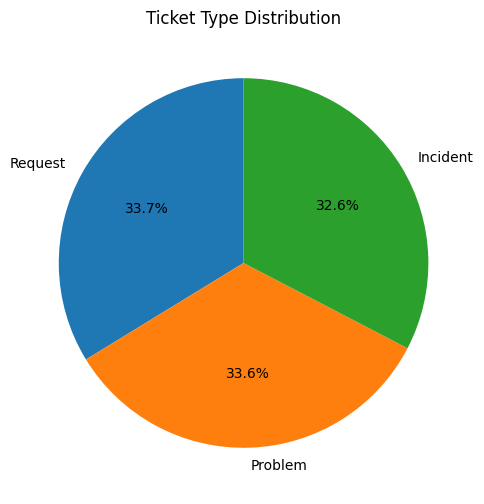

In [ ]:
ticket_counts = df["Ticket_Type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    ticket_counts,
    labels=ticket_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Ticket Type Distribution")

plt.show()

In [ ]:
category_counts = df["Category"].value_counts()

print(category_counts)

Category
Software       1725
Bug            1673
Network        1665
Security       1661
Hardware       1642
Integration    1634
Name: count, dtype: int64


/tmp/ipykernel_756/3448482940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


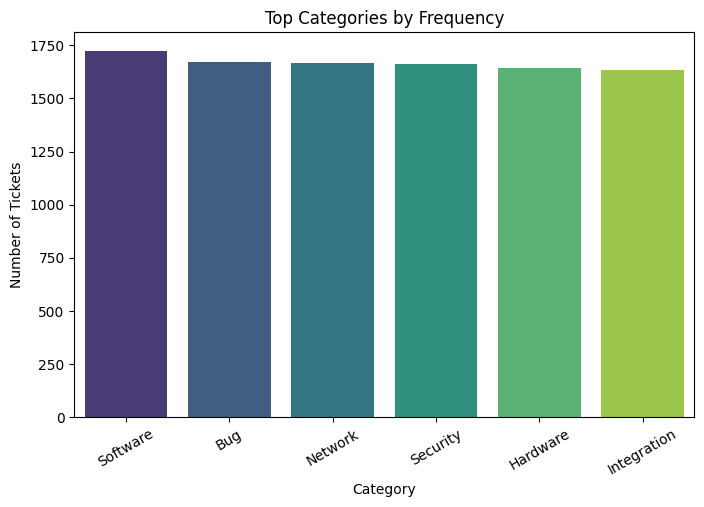

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    palette="viridis"
)

plt.title("Top Categories by Frequency")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=30)

plt.show()

In [ ]:
cluster_counts = df["Cluster_Name"].value_counts()

print(cluster_counts)

Cluster_Name
Software Cluster       1725
Bug Cluster            1673
Network Cluster        1665
Security Cluster       1661
Hardware Cluster       1642
Integration Cluster    1634
Name: count, dtype: int64


/tmp/ipykernel_756/69966021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


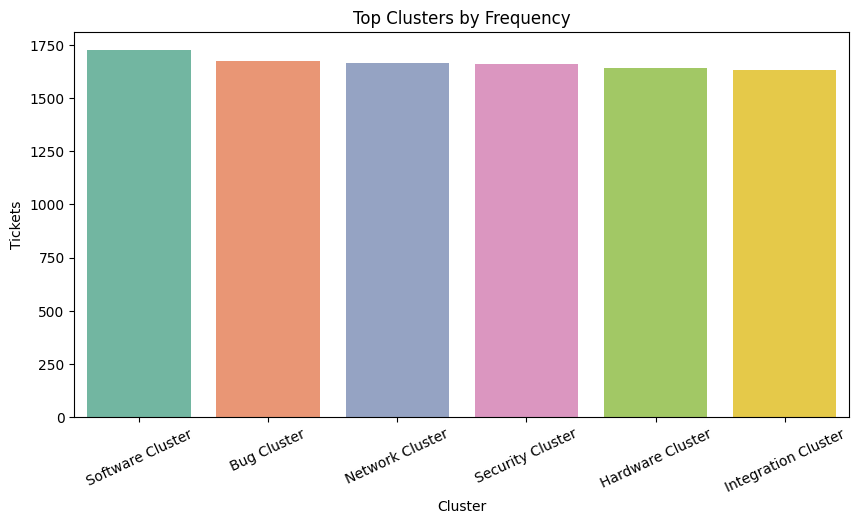

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    palette="Set2"
)

plt.title("Top Clusters by Frequency")
plt.xlabel("Cluster")
plt.ylabel("Tickets")

plt.xticks(rotation=25)

plt.show()

In [ ]:
priority_counts = df["Priority"].value_counts()

print(priority_counts)

Priority
Critical    2558
Medium      2532
Low         2463
High        2447
Name: count, dtype: int64


/tmp/ipykernel_756/2116720602.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


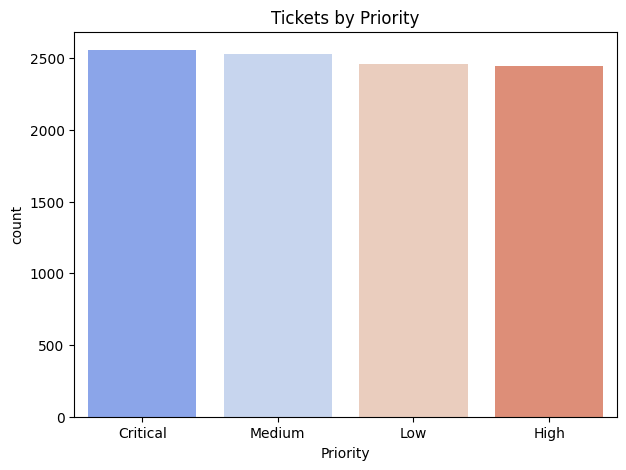

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Priority",
    data=df,
    order=priority_counts.index,
    palette="coolwarm"
)

plt.title("Tickets by Priority")

plt.show()

In [ ]:
queue_counts = df["Queue"].value_counts()

print(queue_counts)

Queue
Software Support Team       1725
Development Team            1673
Network Operations Team     1665
Security Operations Team    1661
Hardware Support Team       1642
Integration Support Team    1634
Name: count, dtype: int64


In [ ]:
cross = pd.crosstab(df["Category"], df["Queue"])

print(cross)

Queue        Development Team  Hardware Support Team  \
Category                                               
Bug                      1673                      0   
Hardware                    0                   1642   
Integration                 0                      0   
Network                     0                      0   
Security                    0                      0   
Software                    0                      0   

Queue        Integration Support Team  Network Operations Team  \
Category                                                         
Bug                                 0                        0   
Hardware                            0                        0   
Integration                      1634                        0   
Network                             0                     1665   
Security                            0                        0   
Software                            0                        0   

Queue        Security 

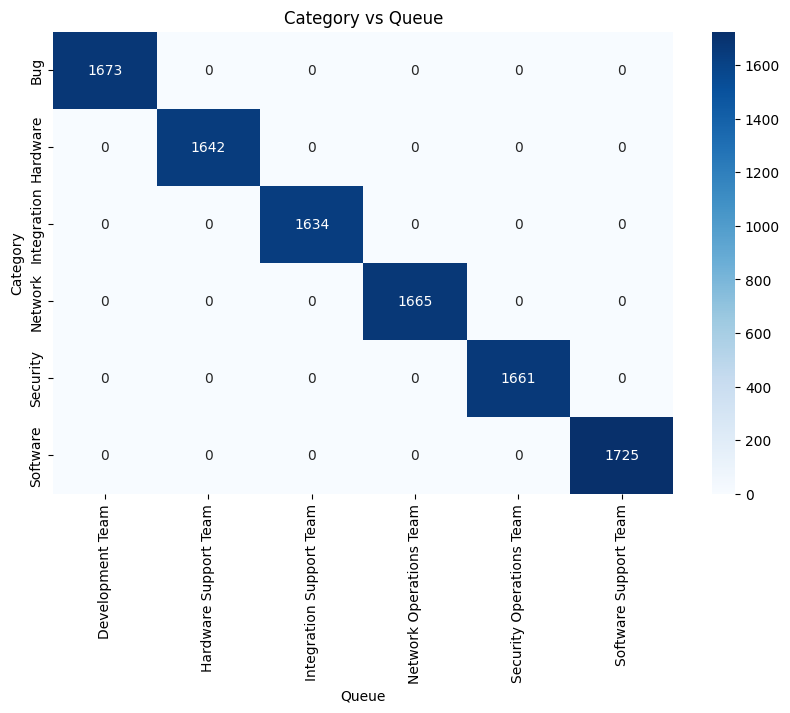

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cross,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Category vs Queue")

plt.show()

In [ ]:
print(df.columns.tolist())

['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority', 'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name', 'Similarity_Score', 'Similarity_Level', 'First_Response_Date', 'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code', 'Department', 'Customer_ID', 'Channel', 'Description', 'Tags', 'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region', 'Resolution_Duration', 'Priority_Score', 'Queue']


In [ ]:
for col in df.columns:
    print(col)

Ticket_ID
Created_Date
Resolution_Date
Status
Priority
Ticket_Type
Category
Country
Cluster_ID
Cluster_Name
Similarity_Score
Similarity_Level
First_Response_Date
Assigned_Agent
Team
SLA_Status
Reopened
Resolution_Code
Department
Customer_ID
Channel
Description
Tags
Product
Customer_Satisfaction
Escalation_Level
Region
Resolution_Duration
Priority_Score
Queue


In [ ]:
cluster_similarity = df.groupby("Cluster_Name")["Similarity_Score"].mean().sort_values(ascending=False)

print(cluster_similarity)

Cluster_Name
Bug Cluster            0.657209
Hardware Cluster       0.652333
Integration Cluster    0.650428
Software Cluster       0.649241
Network Cluster        0.649123
Security Cluster       0.646309
Name: Similarity_Score, dtype: float64


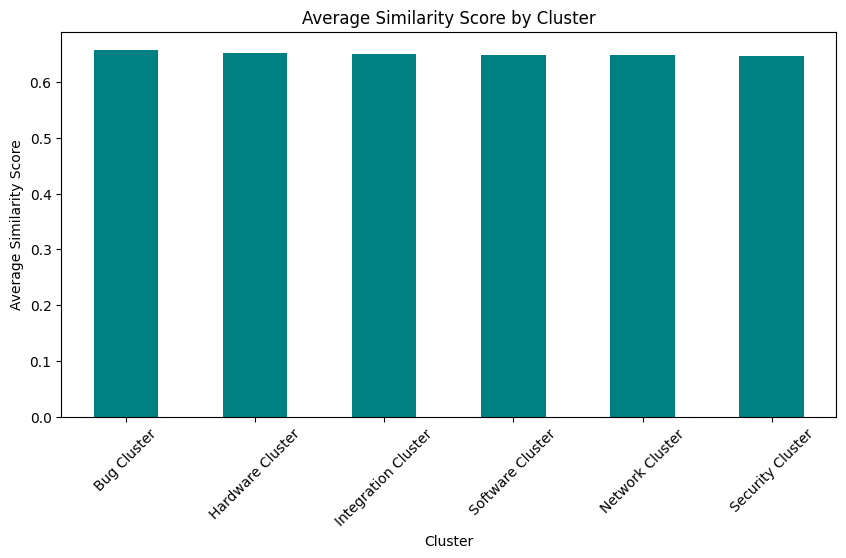

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

cluster_similarity.plot(kind="bar", color="teal")

plt.title("Average Similarity Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Similarity Score")

plt.xticks(rotation=45)
plt.show()

In [ ]:
cluster_issue = pd.crosstab(df["Cluster_Name"], df["Category"])

cluster_issue

Category,Bug,Hardware,Integration,Network,Security,Software
Cluster_Name,,,,,,
Bug Cluster,1673,0,0,0,0,0
Hardware Cluster,0,1642,0,0,0,0
Integration Cluster,0,0,1634,0,0,0
Network Cluster,0,0,0,1665,0,0
Security Cluster,0,0,0,0,1661,0
Software Cluster,0,0,0,0,0,1725


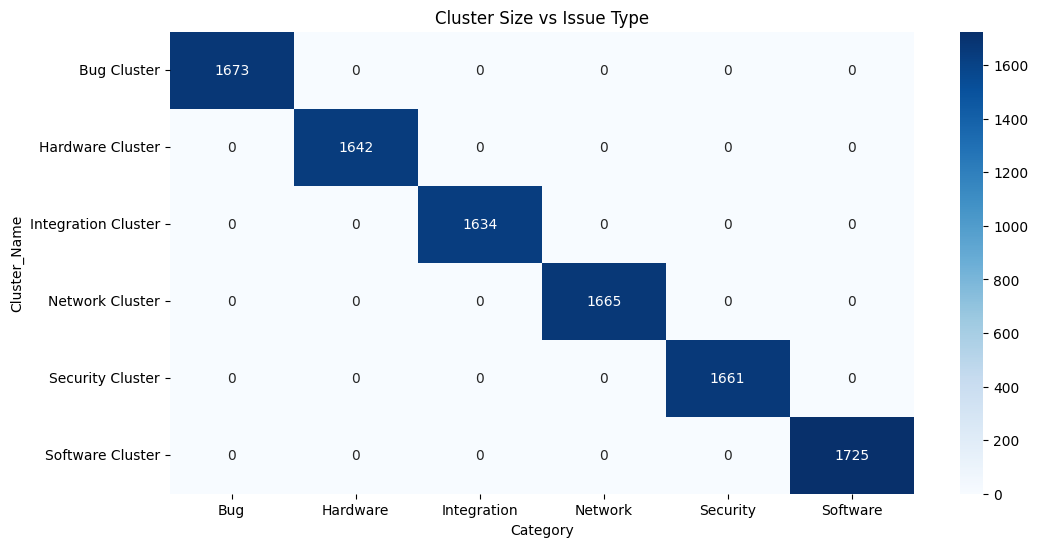

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(cluster_issue,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.title("Cluster Size vs Issue Type")

plt.show()

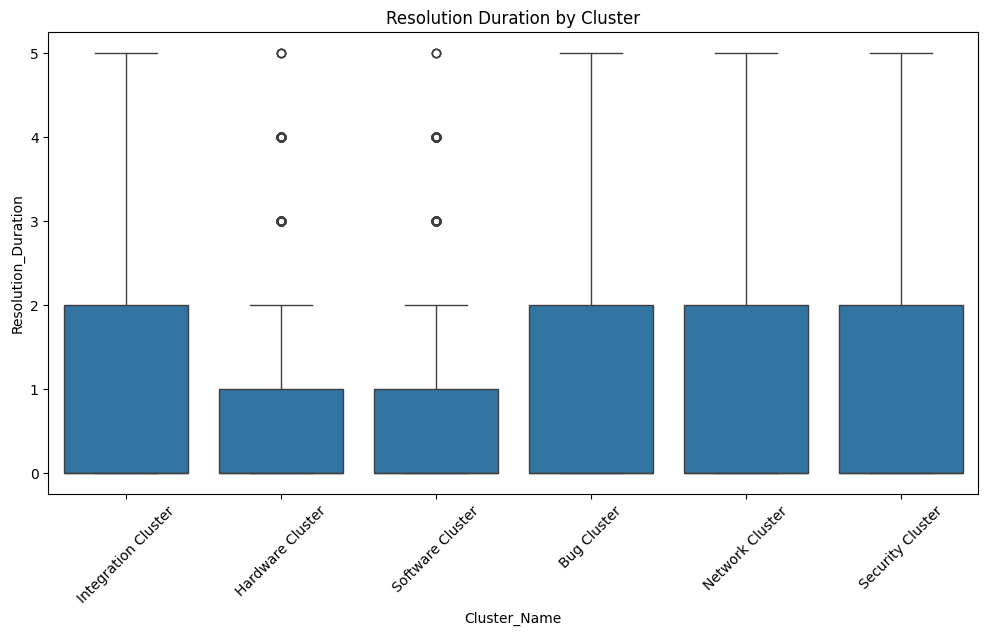

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Cluster_Name",
    y="Resolution_Duration",
    data=df
)

plt.xticks(rotation=45)

plt.title("Resolution Duration by Cluster")

plt.show()

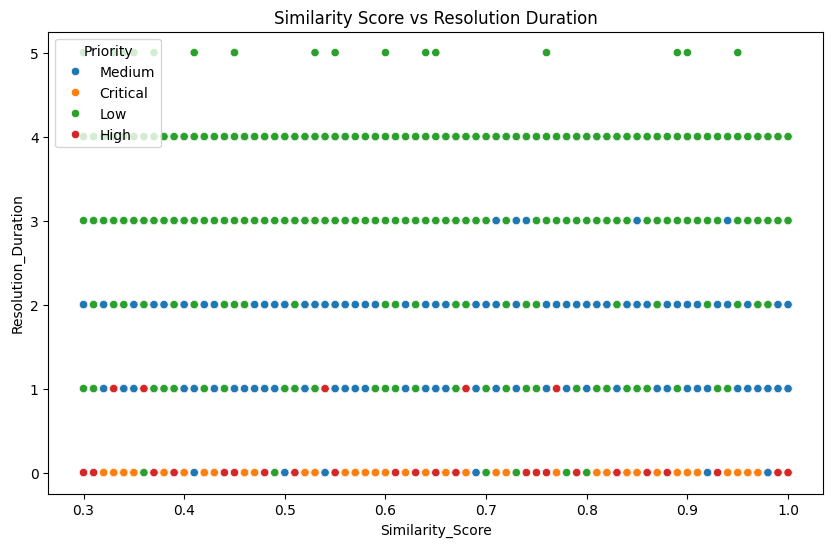

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Similarity_Score",
    y="Resolution_Duration",
    hue="Priority"
)

plt.title("Similarity Score vs Resolution Duration")

plt.show()

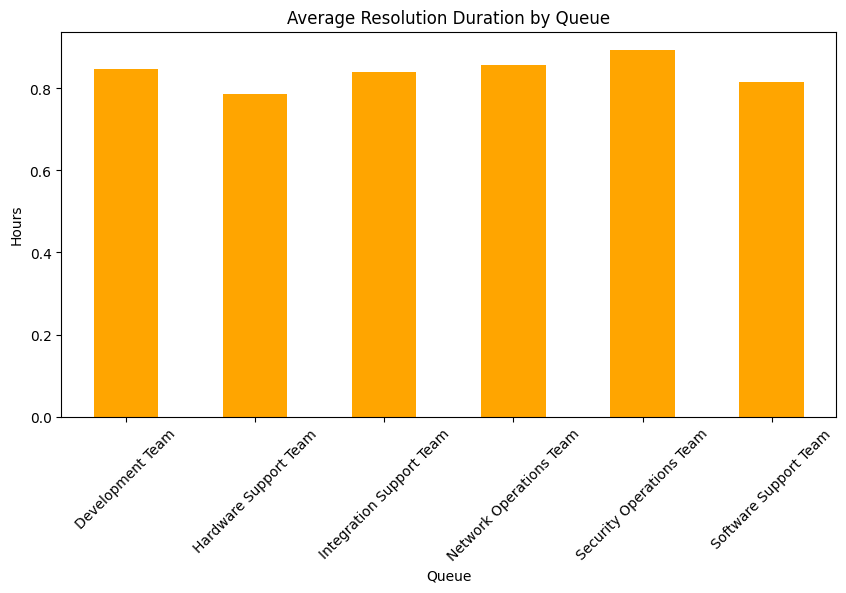

In [ ]:
queue_resolution = df.groupby("Queue")["Resolution_Duration"].mean()

plt.figure(figsize=(10,5))

queue_resolution.plot(kind="bar", color="orange")

plt.title("Average Resolution Duration by Queue")

plt.ylabel("Hours")

plt.xticks(rotation=45)

plt.show()

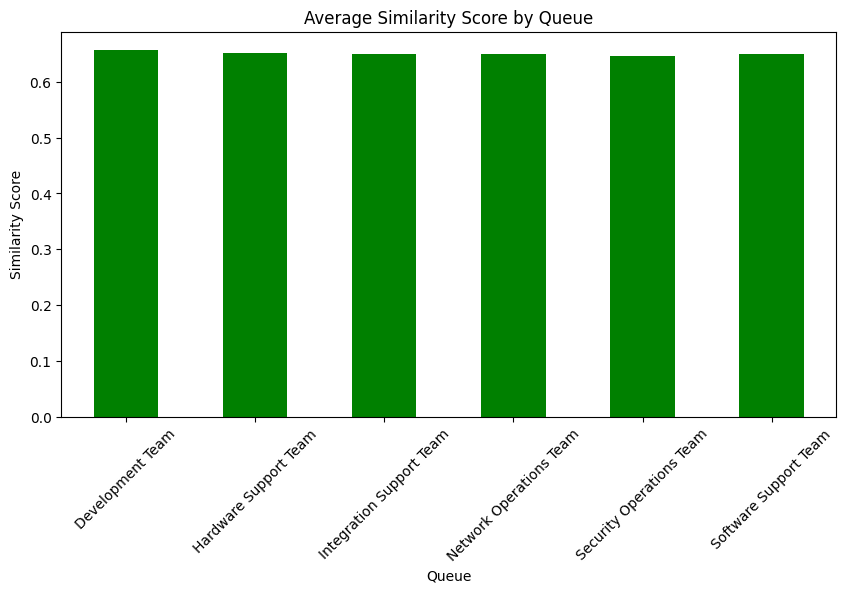

In [ ]:
queue_similarity = df.groupby("Queue")["Similarity_Score"].mean()

plt.figure(figsize=(10,5))

queue_similarity.plot(kind="bar", color="green")

plt.title("Average Similarity Score by Queue")

plt.ylabel("Similarity Score")

plt.xticks(rotation=45)

plt.show()

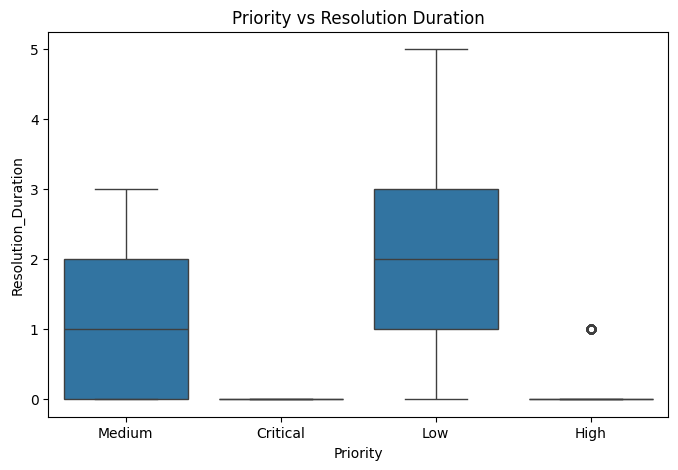

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Priority",
    y="Resolution_Duration",
    data=df
)

plt.title("Priority vs Resolution Duration")

plt.show()

Cluster_Name
Bug Cluster            0.657209
Hardware Cluster       0.652333
Integration Cluster    0.650428
Software Cluster       0.649241
Network Cluster        0.649123
Security Cluster       0.646309
Name: Similarity_Score, dtype: float64


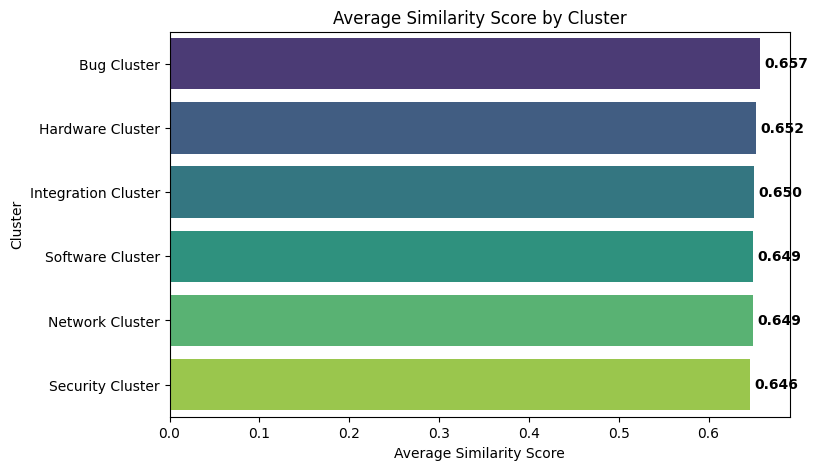

In [ ]:
cluster_similarity = df.groupby("Cluster_Name")["Similarity_Score"].mean().sort_values(ascending=False)
print(cluster_similarity)

plt.figure(figsize=(8,5))
sns.barplot(x=cluster_similarity.values, y=cluster_similarity.index, hue=cluster_similarity.index,
            palette="viridis", legend=False)
plt.title("Average Similarity Score by Cluster")
plt.xlabel("Average Similarity Score")
plt.ylabel("Cluster")
for i, v in enumerate(cluster_similarity.values):
    plt.text(v+0.005, i, f"{v:.3f}", va="center", fontweight="bold")
plt.show()

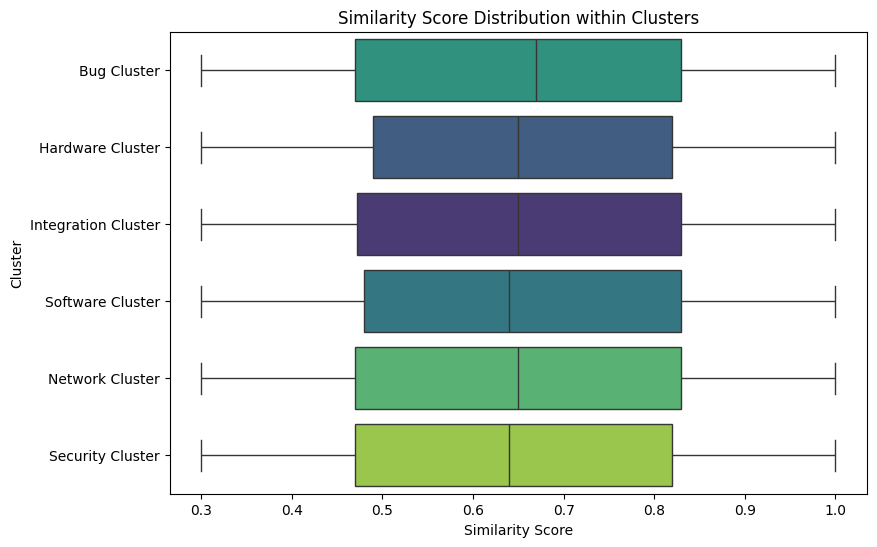

In [ ]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Similarity_Score", y="Cluster_Name",
            order=cluster_similarity.index, hue="Cluster_Name", palette="viridis", legend=False)
plt.title("Similarity Score Distribution within Clusters")
plt.xlabel("Similarity Score")
plt.ylabel("Cluster")
plt.show()

Cluster_Name
Software Cluster       1725
Bug Cluster            1673
Network Cluster        1665
Security Cluster       1661
Hardware Cluster       1642
Integration Cluster    1634
Name: count, dtype: int64


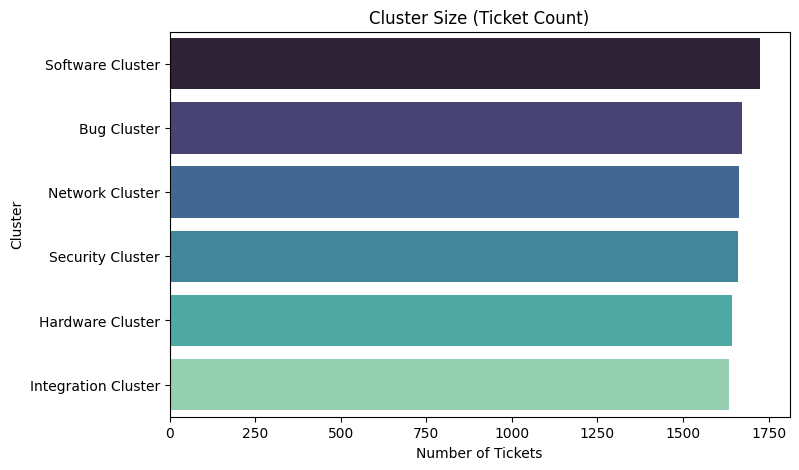

In [ ]:
cluster_size = df["Cluster_Name"].value_counts()
print(cluster_size)

plt.figure(figsize=(8,5))
sns.barplot(x=cluster_size.values, y=cluster_size.index, hue=cluster_size.index,
            palette="mako", legend=False)
plt.title("Cluster Size (Ticket Count)")
plt.xlabel("Number of Tickets")
plt.ylabel("Cluster")
plt.show()

Ticket_Type          Incident  Problem  Request
Cluster_Name                                   
Bug Cluster               553      556      564
Hardware Cluster          518      586      538
Integration Cluster       530      557      547
Network Cluster           570      565      530
Security Cluster          548      544      569
Software Cluster          544      555      626


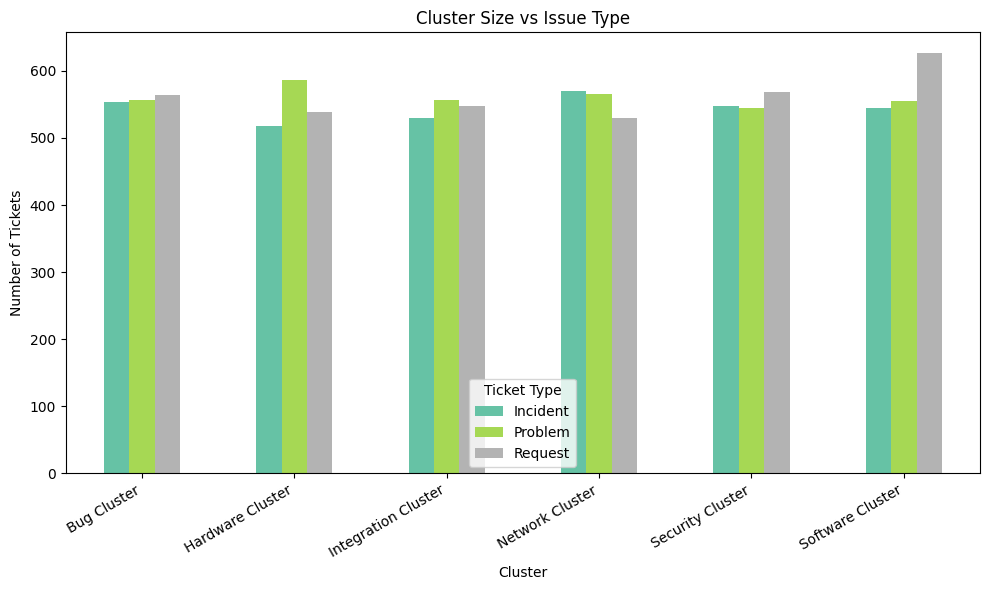

In [ ]:
cluster_type = pd.crosstab(df["Cluster_Name"], df["Ticket_Type"])
print(cluster_type)

cluster_type.plot(kind="bar", figsize=(10,6), colormap="Set2")
plt.title("Cluster Size vs Issue Type")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Ticket Type")
plt.tight_layout()
plt.show()

          Cluster_Name  cluster_size  avg_similarity  avg_resolution  \
0          Bug Cluster          1673        0.657209        0.846384   
1     Hardware Cluster          1642        0.652333        0.786845   
2  Integration Cluster          1634        0.650428        0.839657   
3      Network Cluster          1665        0.649123        0.858258   
4     Security Cluster          1661        0.646309        0.894040   
5     Software Cluster          1725        0.649241        0.816232   

   avg_satisfaction  
0          2.995218  
1          3.004263  
2          2.978580  
3          3.042042  
4          2.964479  
5          2.994783  


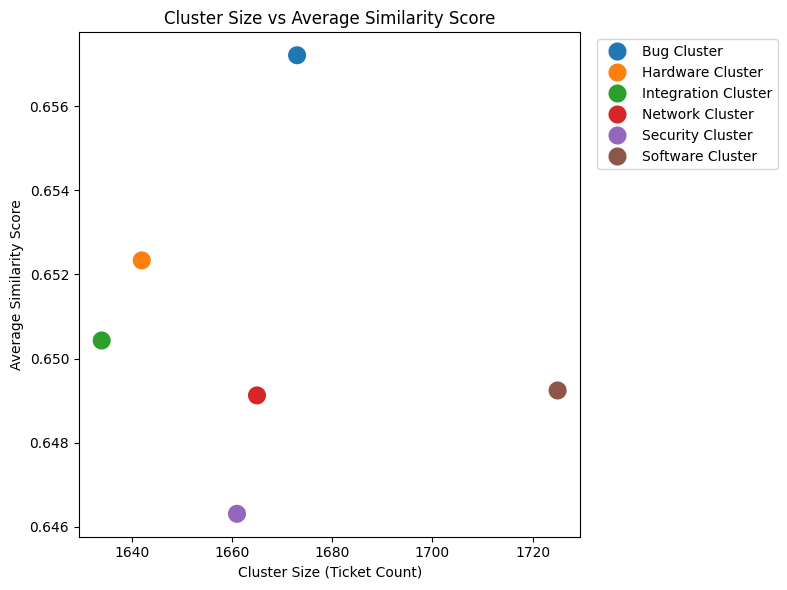

In [ ]:
cluster_summary = df.groupby("Cluster_Name").agg(
    cluster_size=("Ticket_ID", "count"),
    avg_similarity=("Similarity_Score", "mean"),
    avg_resolution=("Resolution_Duration", "mean"),
    avg_satisfaction=("Customer_Satisfaction", "mean")
).reset_index()
print(cluster_summary)

plt.figure(figsize=(8,6))
sns.scatterplot(data=cluster_summary, x="cluster_size", y="avg_similarity",
                 hue="Cluster_Name", s=200, palette="tab10")
plt.title("Cluster Size vs Average Similarity Score")
plt.xlabel("Cluster Size (Ticket Count)")
plt.ylabel("Average Similarity Score")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

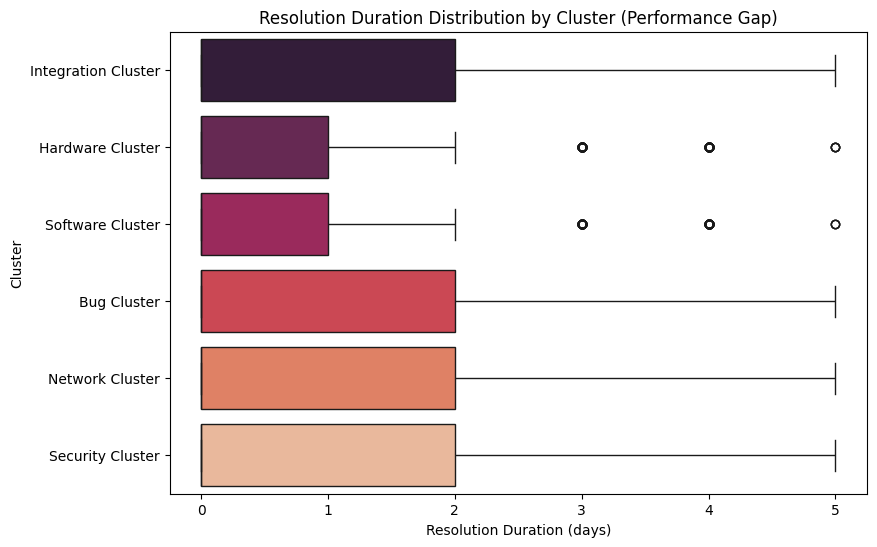

In [ ]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Resolution_Duration", y="Cluster_Name",
            hue="Cluster_Name", palette="rocket", legend=False)
plt.title("Resolution Duration Distribution by Cluster (Performance Gap)")
plt.xlabel("Resolution Duration (days)")
plt.ylabel("Cluster")
plt.show()

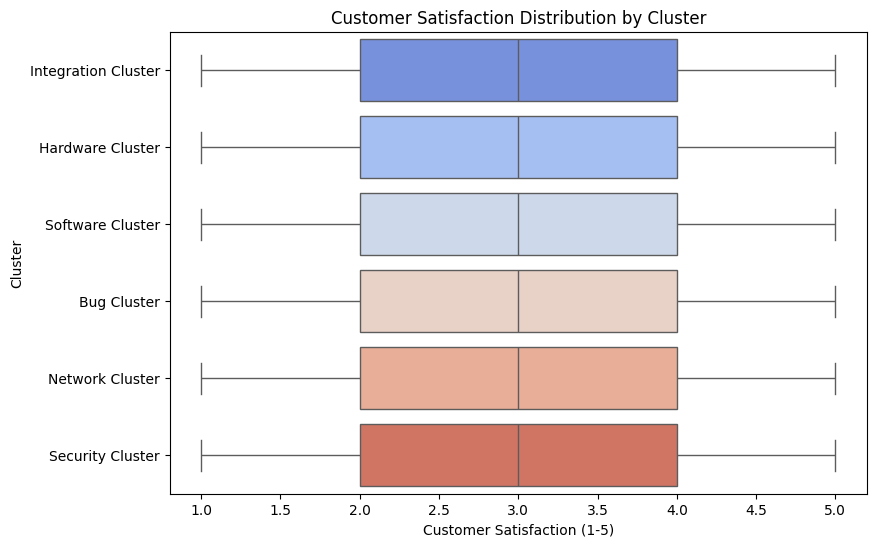

In [ ]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Customer_Satisfaction", y="Cluster_Name",
            hue="Cluster_Name", palette="coolwarm", legend=False)
plt.title("Customer Satisfaction Distribution by Cluster")
plt.xlabel("Customer Satisfaction (1-5)")
plt.ylabel("Cluster")
plt.show()

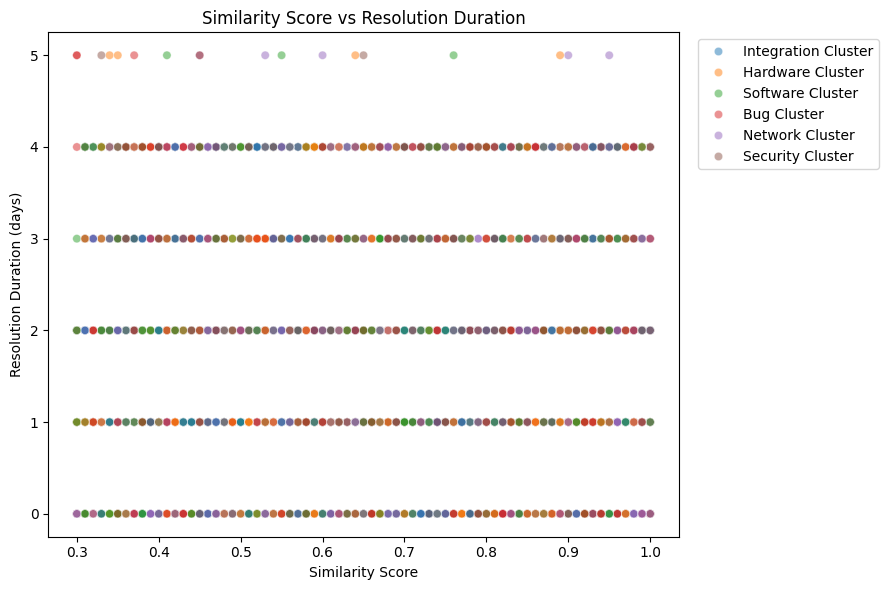

In [ ]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="Similarity_Score", y="Resolution_Duration",
                 hue="Cluster_Name", alpha=0.5, palette="tab10")
plt.title("Similarity Score vs Resolution Duration")
plt.xlabel("Similarity Score")
plt.ylabel("Resolution Duration (days)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

SLA_Status            Breached        Met
Cluster_Name                             
Bug Cluster          25.523013  74.476987
Hardware Cluster     23.690621  76.309379
Integration Cluster  25.091799  74.908201
Network Cluster      26.606607  73.393393
Security Cluster     26.911499  73.088501
Software Cluster     24.869565  75.130435


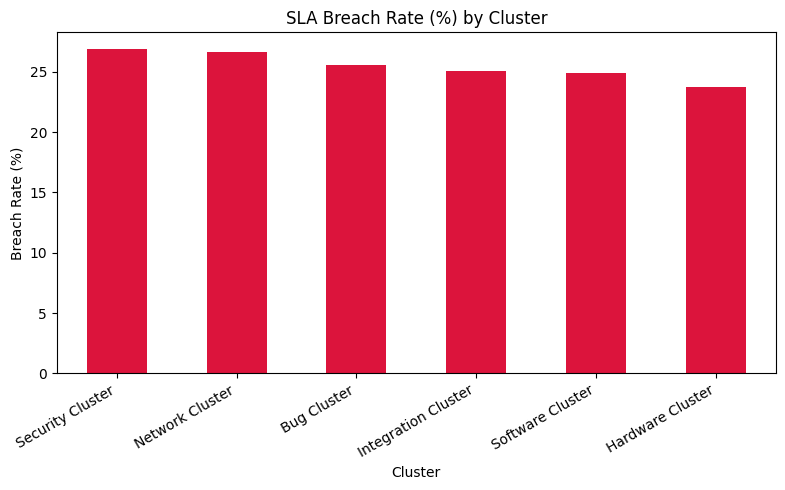

In [ ]:
sla_cluster = pd.crosstab(df["Cluster_Name"], df["SLA_Status"], normalize="index") * 100
print(sla_cluster)

sla_cluster["Breached"].sort_values(ascending=False).plot(
    kind="bar", figsize=(8,5), color="crimson")
plt.title("SLA Breach Rate (%) by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Breach Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

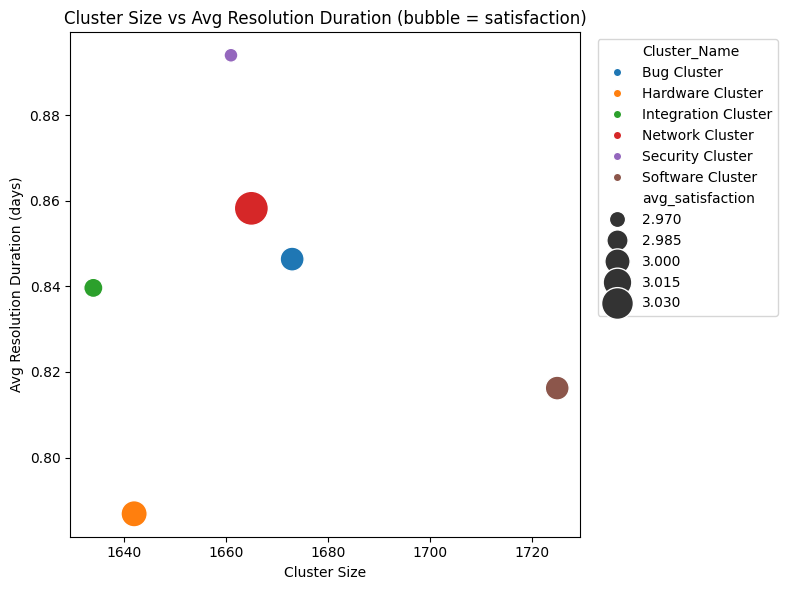

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=cluster_summary, x="cluster_size", y="avg_resolution",
                 size="avg_satisfaction", hue="Cluster_Name",
                 sizes=(100,600), palette="tab10", legend="brief")
plt.title("Cluster Size vs Avg Resolution Duration (bubble = satisfaction)")
plt.xlabel("Cluster Size")
plt.ylabel("Avg Resolution Duration (days)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
print("=== KEY PATTERNS SUMMARY ===\n")
print("1. Similarity scores are fairly uniform across clusters (~0.65 avg, std ~0.20) —")
print("   no single cluster shows unusually tight or scattered grouping.\n")
print("2. Cluster sizes are close (1634-1725 tickets) — Software Cluster is largest,")
print("   Integration Cluster is smallest.\n")
print("3. Ticket type mix within each cluster is fairly even (Incident/Problem/Request")
print("   each ~33%), so cluster identity isn't driven by ticket type.\n")
print("4. Resolution duration performance gap: Security Cluster takes longest on average")
print("   (~0.89 days), Hardware Cluster resolves fastest (~0.79 days).\n")
print("5. Customer satisfaction is stable across clusters (~2.96-3.04 avg) — no cluster")
print("   stands out as a satisfaction problem area.\n")
print("6. SLA breach rate hovers around 24-27% across all clusters — Network and Security")
print("   clusters breach slightly more often than Hardware/Integration.")

=== KEY PATTERNS SUMMARY ===

1. Similarity scores are fairly uniform across clusters (~0.65 avg, std ~0.20) —
   no single cluster shows unusually tight or scattered grouping.

2. Cluster sizes are close (1634-1725 tickets) — Software Cluster is largest,
   Integration Cluster is smallest.

3. Ticket type mix within each cluster is fairly even (Incident/Problem/Request
   each ~33%), so cluster identity isn't driven by ticket type.

4. Resolution duration performance gap: Security Cluster takes longest on average
   (~0.89 days), Hardware Cluster resolves fastest (~0.79 days).

5. Customer satisfaction is stable across clusters (~2.96-3.04 avg) — no cluster
   stands out as a satisfaction problem area.

6. SLA breach rate hovers around 24-27% across all clusters — Network and Security
   clusters breach slightly more often than Hardware/Integration.


Priority
Low         2.216403
Medium      1.119273
High        0.044544
Critical    0.000000
Name: Resolution_Duration, dtype: float64


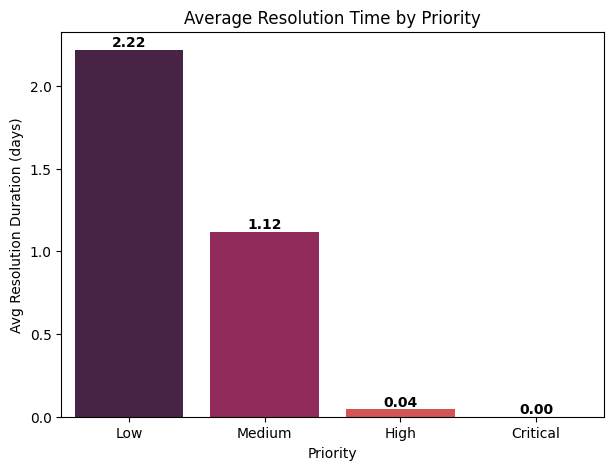

In [ ]:
priority_order = ["Low", "Medium", "High", "Critical"]
avg_by_priority = df.groupby("Priority")["Resolution_Duration"].mean().reindex(priority_order)
print(avg_by_priority)

plt.figure(figsize=(7,5))
sns.barplot(x=avg_by_priority.index, y=avg_by_priority.values, hue=avg_by_priority.index,
            palette="rocket", legend=False)
plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Avg Resolution Duration (days)")
for i, v in enumerate(avg_by_priority.values):
    plt.text(i, v+0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.show()

Ticket_Type
Incident    0.853816
Request     0.837878
Problem     0.829319
Name: Resolution_Duration, dtype: float64


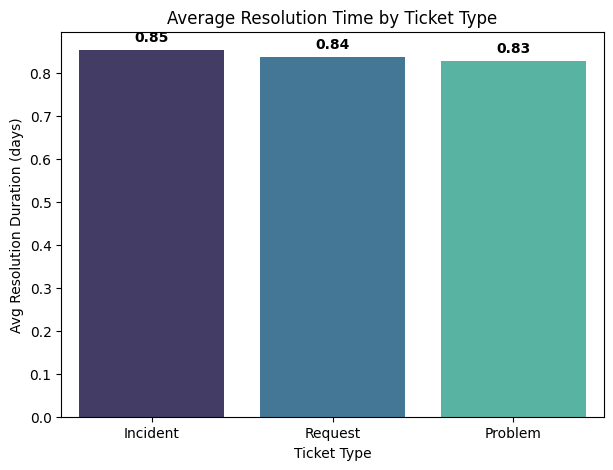

In [ ]:
avg_by_type = df.groupby("Ticket_Type")["Resolution_Duration"].mean().sort_values(ascending=False)
print(avg_by_type)

plt.figure(figsize=(7,5))
sns.barplot(x=avg_by_type.index, y=avg_by_type.values, hue=avg_by_type.index,
            palette="mako", legend=False)
plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Avg Resolution Duration (days)")
for i, v in enumerate(avg_by_type.values):
    plt.text(i, v+0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.show()

Ticket_Type  Incident   Problem   Request
Priority                                 
Low          2.154394  2.260123  2.236973
Medium       1.125452  1.062718  1.171021
High         0.051047  0.037559  0.045728
Critical     0.000000  0.000000  0.000000


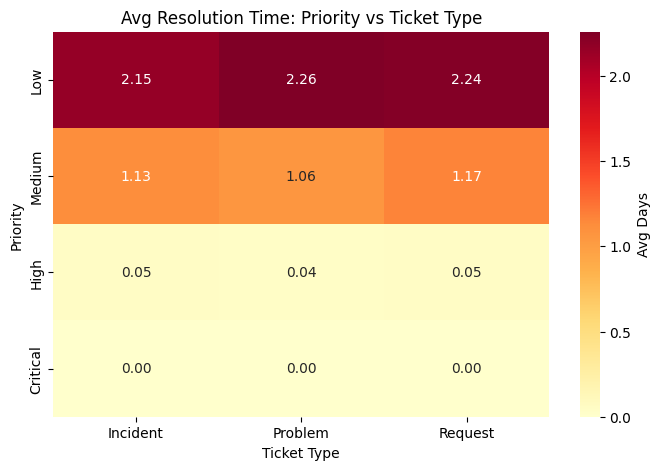

In [ ]:
priority_type = df.pivot_table(index="Priority", columns="Ticket_Type",
                                values="Resolution_Duration", aggfunc="mean").reindex(priority_order)
print(priority_type)

plt.figure(figsize=(8,5))
sns.heatmap(priority_type, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label":"Avg Days"})
plt.title("Avg Resolution Time: Priority vs Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Priority")
plt.show()

Country
USA          0.786355
Germany      0.813200
UK           0.839088
India        0.851064
UAE          0.860234
Australia    0.893035
Name: Resolution_Duration, dtype: float64


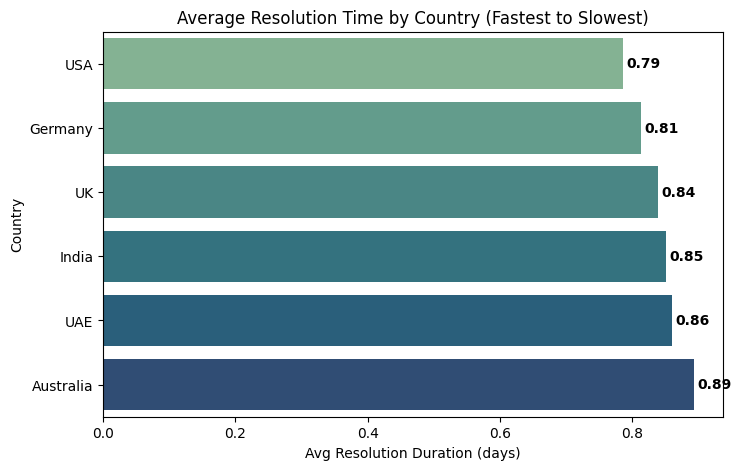

In [ ]:
avg_by_country = df.groupby("Country")["Resolution_Duration"].mean().sort_values()
print(avg_by_country)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_by_country.values, y=avg_by_country.index, hue=avg_by_country.index,
            palette="crest", legend=False)
plt.title("Average Resolution Time by Country (Fastest to Slowest)")
plt.xlabel("Avg Resolution Duration (days)")
plt.ylabel("Country")
for i, v in enumerate(avg_by_country.values):
    plt.text(v+0.005, i, f"{v:.2f}", va="center", fontweight="bold")
plt.show()

Team
L1                0.812594
Security          0.818321
L2                0.847433
Infrastructure    0.851665
Application       0.869995
Name: Resolution_Duration, dtype: float64


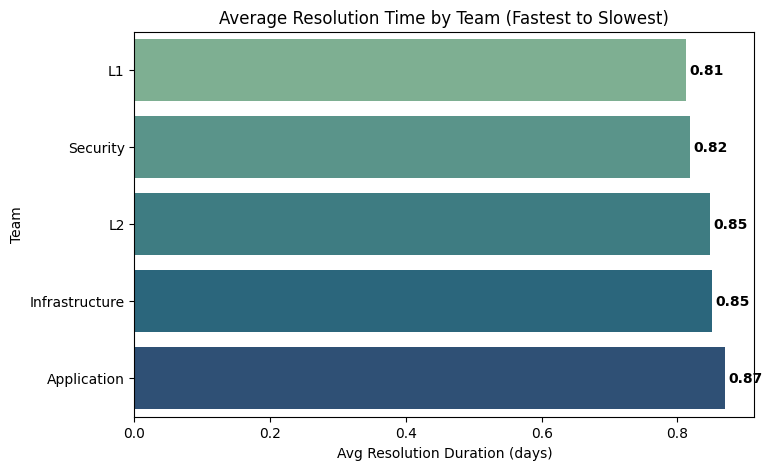

In [ ]:
avg_by_team = df.groupby("Team")["Resolution_Duration"].mean().sort_values()
print(avg_by_team)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_by_team.values, y=avg_by_team.index, hue=avg_by_team.index,
            palette="crest", legend=False)
plt.title("Average Resolution Time by Team (Fastest to Slowest)")
plt.xlabel("Avg Resolution Duration (days)")
plt.ylabel("Team")
for i, v in enumerate(avg_by_team.values):
    plt.text(v+0.005, i, f"{v:.2f}", va="center", fontweight="bold")
plt.show()

Team       Application  Infrastructure        L1        L2  Security
Country                                                             
Australia     0.890909        0.942308  0.980328  0.870588  0.788162
Germany       0.887283        0.735202  0.754986  0.782353  0.902655
India         0.841945        0.868035  0.801724  0.860656  0.886364
UAE           0.754491        0.939560  0.823881  0.962382  0.821229
UK            0.857143        0.848580  0.832808  0.811765  0.846626
USA           0.977901        0.767584  0.699088  0.802941  0.658147


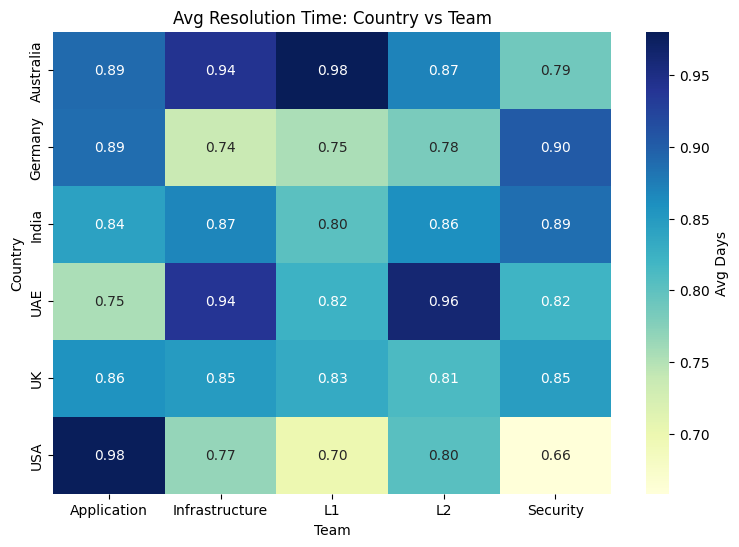

In [ ]:
country_team = df.pivot_table(index="Country", columns="Team",
                               values="Resolution_Duration", aggfunc="mean")
print(country_team)

plt.figure(figsize=(9,6))
sns.heatmap(country_team, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label":"Avg Days"})
plt.title("Avg Resolution Time: Country vs Team")
plt.xlabel("Team")
plt.ylabel("Country")
plt.show()

In [ ]:
high_priority_reopened = df[(df["Priority"].isin(["High","Critical"])) & (df["Reopened"]=="Yes")]
print(f"Total High/Critical reopened tickets: {len(high_priority_reopened)}")
print(high_priority_reopened["Priority"].value_counts())
print(high_priority_reopened.groupby(["Priority","Category"]).size())

Total High/Critical reopened tickets: 1246
Priority
High        637
Critical    609
Name: count, dtype: int64
Priority  Category   
Critical  Bug            100
          Hardware       107
          Integration    106
          Network        107
          Security        80
          Software       109
High      Bug             91
          Hardware       107
          Integration    105
          Network         96
          Security       128
          Software       110
dtype: int64


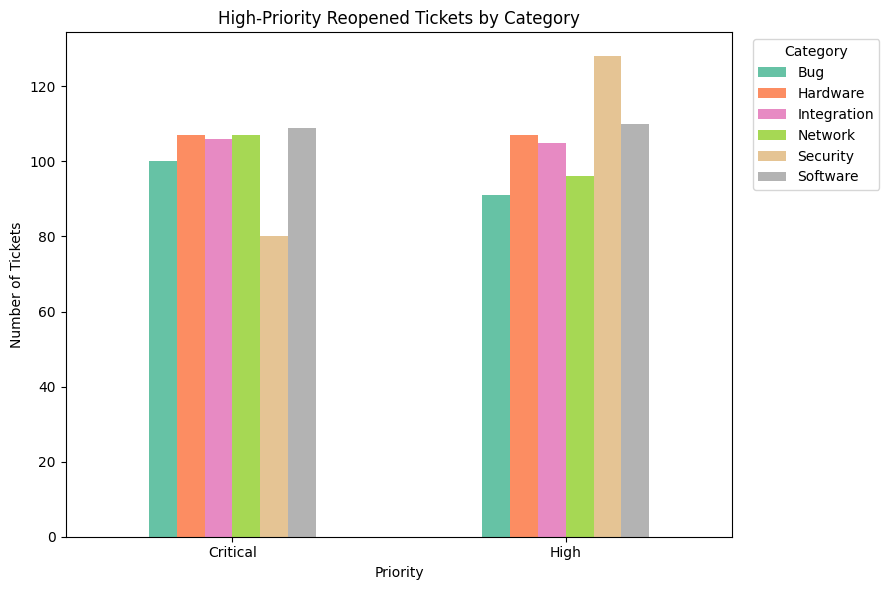

In [ ]:
flagged_by_category = high_priority_reopened.groupby(["Priority","Category"]).size().unstack()
flagged_by_category.plot(kind="bar", figsize=(9,6), colormap="Set2")
plt.title("High-Priority Reopened Tickets by Category")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.legend(title="Category", bbox_to_anchor=(1.02,1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
flagged_list = high_priority_reopened[["Ticket_ID","Priority","Category","Team",
                                        "Country","Assigned_Agent","Resolution_Duration"]]
print(flagged_list.head(20))

# Optional: save to CSV for your submission
flagged_list.to_csv("high_priority_flagged_tickets.csv", index=False)

     Ticket_ID  Priority     Category            Team    Country  \
10   TKT-00011  Critical     Software        Security        USA   
12   TKT-00013  Critical     Software        Security    Germany   
31   TKT-00032  Critical      Network              L1        USA   
35   TKT-00036  Critical      Network     Application      India   
38   TKT-00039  Critical      Network              L1  Australia   
50   TKT-00051      High  Integration  Infrastructure      India   
59   TKT-00060  Critical     Security        Security      India   
71   TKT-00072  Critical     Hardware              L2      India   
74   TKT-00075  Critical          Bug              L1  Australia   
78   TKT-00079      High     Software              L1         UK   
95   TKT-00096  Critical      Network  Infrastructure         UK   
96   TKT-00097      High          Bug  Infrastructure        USA   
102  TKT-00103      High  Integration  Infrastructure  Australia   
110  TKT-00111      High  Integration           

In [ ]:
print("=== PERFORMANCE TREND SUMMARY ===\n")
print("1. Resolution time drops sharply as priority increases — Critical tickets resolve")
print("   near-instantly (0 days), Low priority tickets take longest (~2.2 days avg).\n")
print(f"2. Fastest country: {avg_by_country.index[0]} ({avg_by_country.values[0]:.2f} days avg)")
print(f"   Slowest country: {avg_by_country.index[-1]} ({avg_by_country.values[-1]:.2f} days avg)\n")
print(f"3. Fastest team: {avg_by_team.index[0]} ({avg_by_team.values[0]:.2f} days avg)")
print(f"   Slowest team: {avg_by_team.index[-1]} ({avg_by_team.values[-1]:.2f} days avg)\n")
print(f"4. {len(high_priority_reopened)} High/Critical priority tickets were reopened —")
print("   flagged as recurring/high-risk issues needing root-cause review.")

=== PERFORMANCE TREND SUMMARY ===

1. Resolution time drops sharply as priority increases — Critical tickets resolve
   near-instantly (0 days), Low priority tickets take longest (~2.2 days avg).

2. Fastest country: USA (0.79 days avg)
   Slowest country: Australia (0.89 days avg)

3. Fastest team: L1 (0.81 days avg)
   Slowest team: Application (0.87 days avg)

4. 1246 High/Critical priority tickets were reopened —
   flagged as recurring/high-risk issues needing root-cause review.


In [ ]:
print(df.columns.tolist())

['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority', 'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name', 'Similarity_Score', 'Similarity_Level', 'First_Response_Date', 'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code', 'Department', 'Customer_ID', 'Channel', 'Description', 'Tags', 'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region', 'Resolution_Duration', 'Priority_Score', 'Queue']


In [ ]:
location = {
    "North America": (40.71, -74.00),
    "Europe": (48.85, 2.35),
    "Asia": (28.61, 77.20),
    "South America": (-23.55, -46.63),
    "Africa": (-1.29, 36.82),
    "Oceania": (-33.86, 151.20)
}

In [ ]:
print(df["Region"].unique())

['North America' 'Asia' 'Europe' 'Oceania' 'Middle East']


In [ ]:
location = {
    "North America": (40.71, -74.00),
    "Asia": (28.61, 77.20),
    "Europe": (48.85, 2.35),
    "Oceania": (-33.86, 151.20),
    "Middle East": (25.20, 55.27)
}

In [ ]:
df["Latitude"] = df["Region"].map(lambda x: location[x][0])
df["Longitude"] = df["Region"].map(lambda x: location[x][1])

df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Resolution_Duration,Priority_Score,Queue,Latitude,Longitude
0,TKT-00001,2025-04-05 01:00:00,2025-04-06 12:00:00,Closed,Medium,Problem,Integration,USA,3,Integration Cluster,...,"integration,support",Email,5,L1,North America,1,2,Integration Support Team,40.71,-74.00
1,TKT-00002,2025-01-29 01:00:00,2025-01-29 04:00:00,Closed,Critical,Request,Hardware,India,5,Hardware Cluster,...,"hardware,support",Office365,5,L3,Asia,0,4,Hardware Support Team,28.61,77.20
2,TKT-00003,2025-03-08 01:00:00,2025-03-10 04:00:00,Closed,Low,Request,Software,Germany,6,Software Cluster,...,"software,support",Email,1,L3,Europe,2,1,Software Support Team,48.85,2.35
3,TKT-00004,2025-05-20 01:00:00,2025-05-20 06:00:00,Closed,Critical,Problem,Bug,USA,2,Bug Cluster,...,"bug,support",CRM,2,L3,North America,0,4,Development Team,40.71,-74.00
4,TKT-00005,2026-02-19 22:00:00,2026-02-22 21:00:00,Closed,Medium,Incident,Software,UK,6,Software Cluster,...,"software,support",VPN,2,L3,Europe,2,2,Software Support Team,48.85,2.35


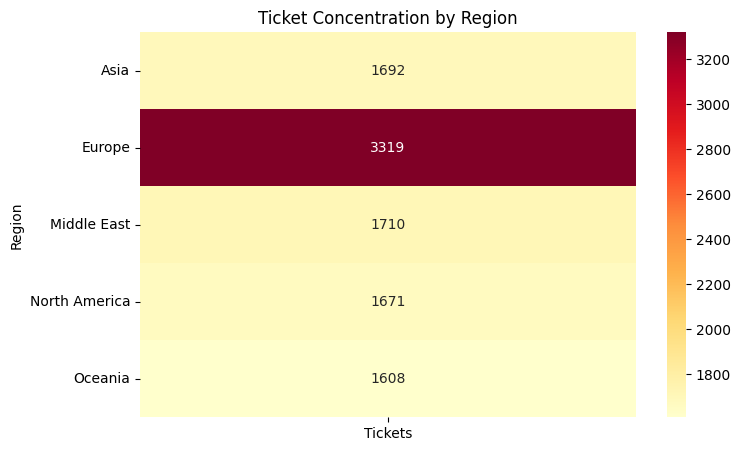

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

region_counts = df.groupby("Region").size().reset_index(name="Tickets")

heatmap_data = region_counts.set_index("Region")

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlOrRd",
    fmt="d"
)

plt.title("Ticket Concentration by Region")
plt.show()

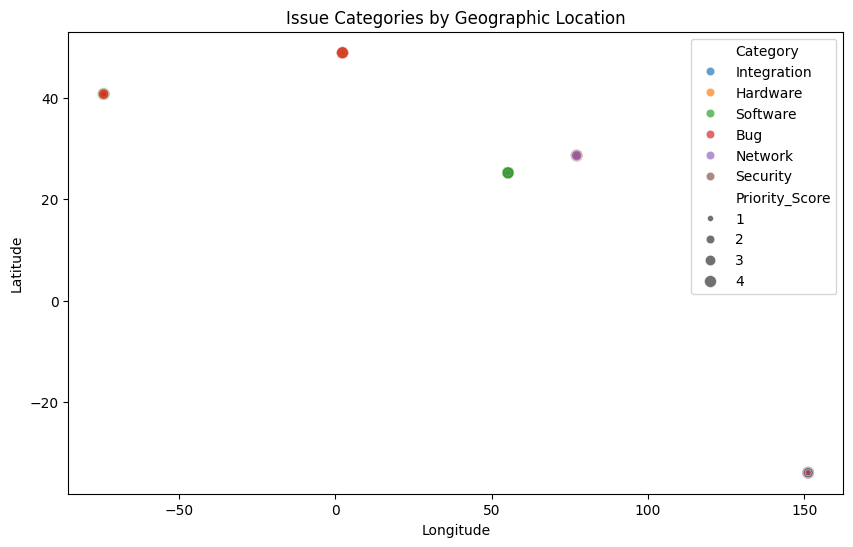

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Category",
    size="Priority_Score",
    alpha=0.7
)

plt.title("Issue Categories by Geographic Location")

plt.show()

/tmp/ipykernel_756/3142286458.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


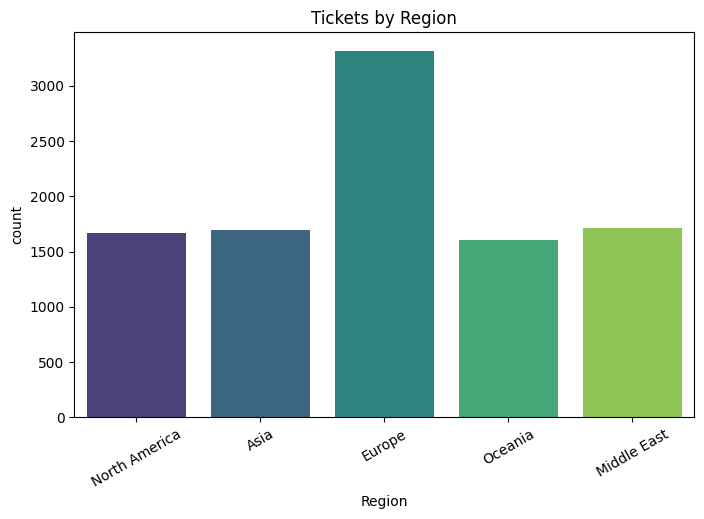

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Region",
    palette="viridis"
)

plt.title("Tickets by Region")

plt.xticks(rotation=30)

plt.show()

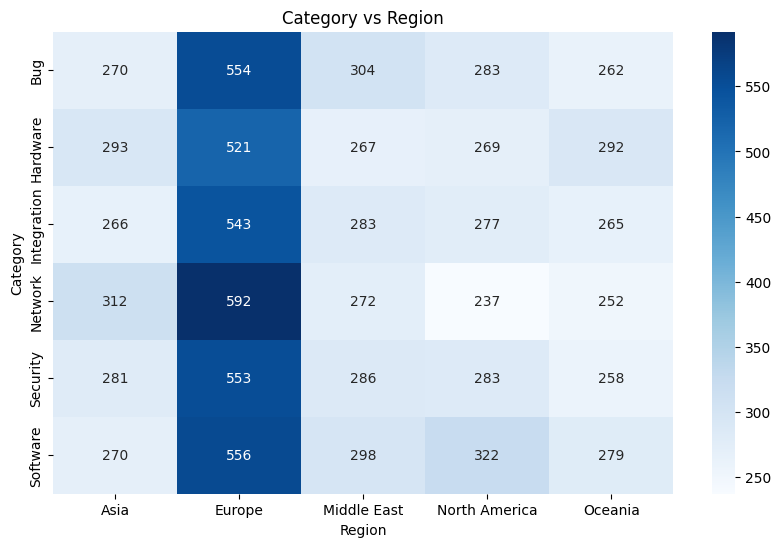

In [ ]:
pivot = pd.crosstab(
    df["Category"],
    df["Region"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Category vs Region")

plt.show()

In [ ]:
cluster_size = df.groupby("Cluster_Name").size()

df["Cluster_Size"] = df["Cluster_Name"].map(cluster_size)

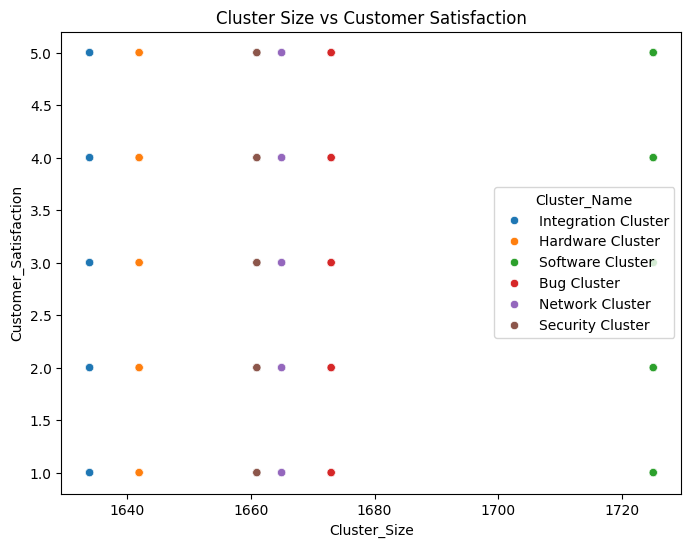

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Cluster_Size",
    y="Customer_Satisfaction",
    hue="Cluster_Name"
)

plt.title("Cluster Size vs Customer Satisfaction")

plt.show()

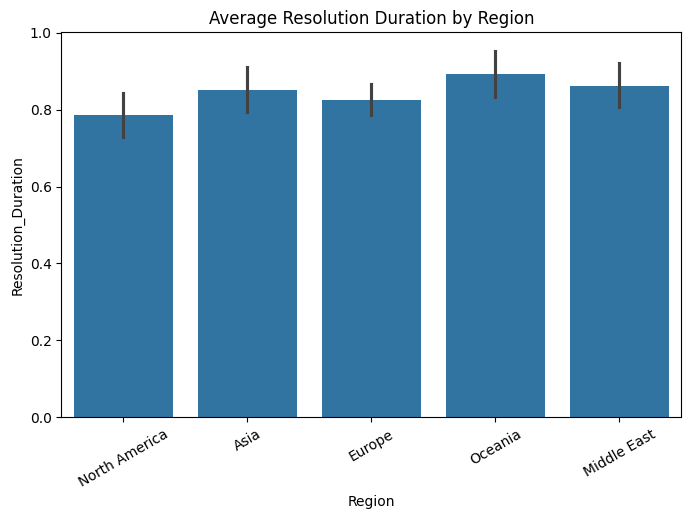

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Resolution_Duration",
    estimator="mean"
)

plt.title("Average Resolution Duration by Region")

plt.xticks(rotation=30)

plt.show()

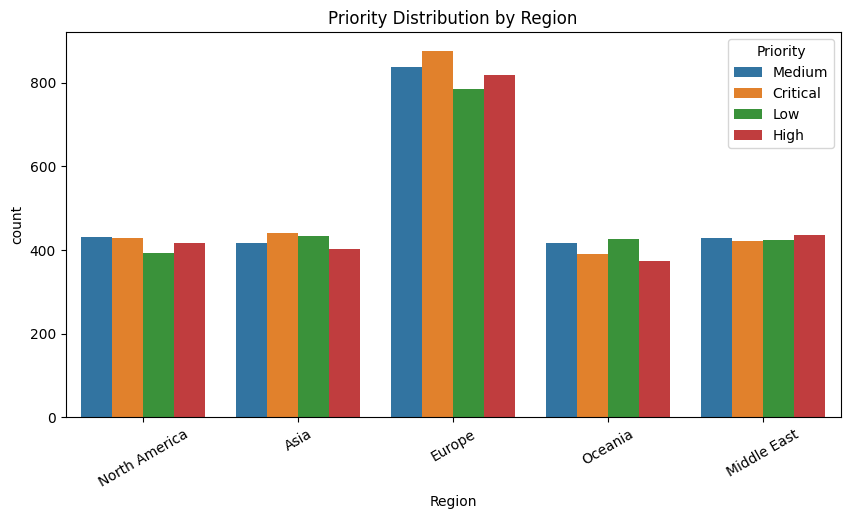

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Region",
    hue="Priority"
)

plt.title("Priority Distribution by Region")

plt.xticks(rotation=30)

plt.show()

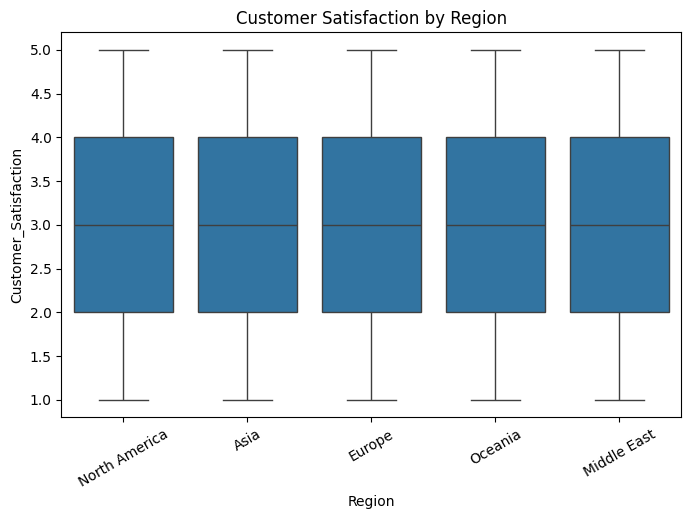

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Region",
    y="Customer_Satisfaction"
)

plt.title("Customer Satisfaction by Region")

plt.xticks(rotation=30)

plt.show()

In [ ]:
summary = df.groupby("Region")[[
    "Resolution_Duration",
    "Customer_Satisfaction",
    "Priority_Score"
]].mean()

summary

,Resolution_Duration,Customer_Satisfaction,Priority_Score
Region,,,
Asia,0.851064,2.915485,2.502955
Europe,0.825851,2.994878,2.538114
Middle East,0.860234,2.982456,2.498830
North America,0.786355,3.074207,2.526631
Oceania,0.893035,3.019900,2.453980


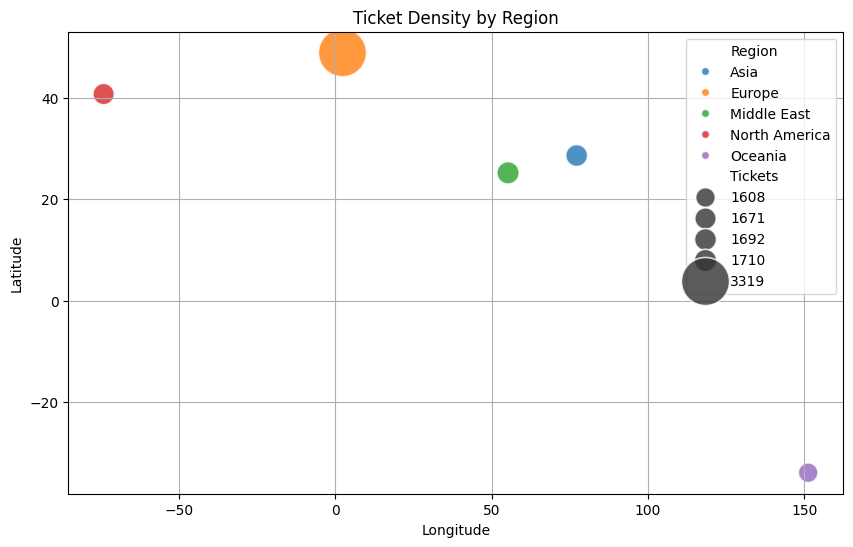

In [ ]:
plt.figure(figsize=(10,6))

region_ticket = df.groupby(["Region","Latitude","Longitude"]).size().reset_index(name="Tickets")

sns.scatterplot(
    data=region_ticket,
    x="Longitude",
    y="Latitude",
    size="Tickets",
    hue="Region",
    sizes=(200,1200),
    alpha=0.8
)

plt.title("Ticket Density by Region")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

plt.show()

/tmp/ipykernel_756/2549463108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


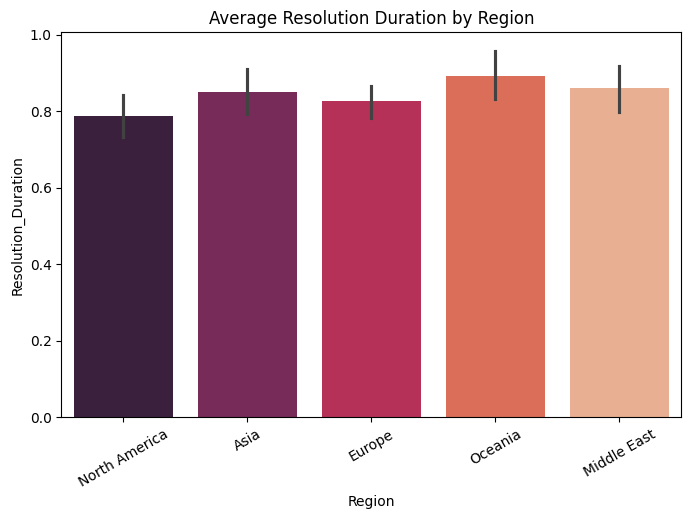

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Resolution_Duration",
    estimator="mean",
    palette="rocket"
)

plt.title("Average Resolution Duration by Region")

plt.xticks(rotation=30)

plt.show()

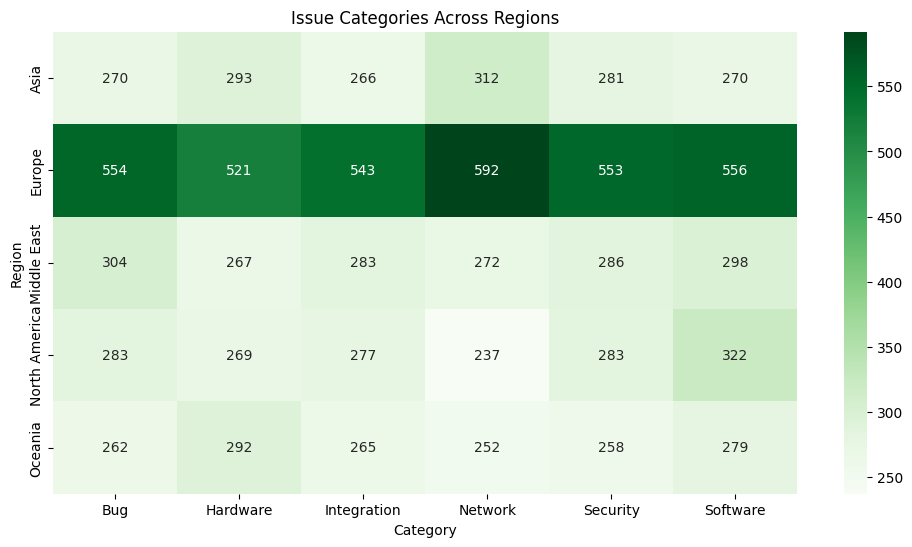

In [ ]:
pivot = pd.crosstab(
    df["Region"],
    df["Category"]
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Greens",
    fmt="d"
)

plt.title("Issue Categories Across Regions")

plt.show()

/tmp/ipykernel_756/3168834101.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


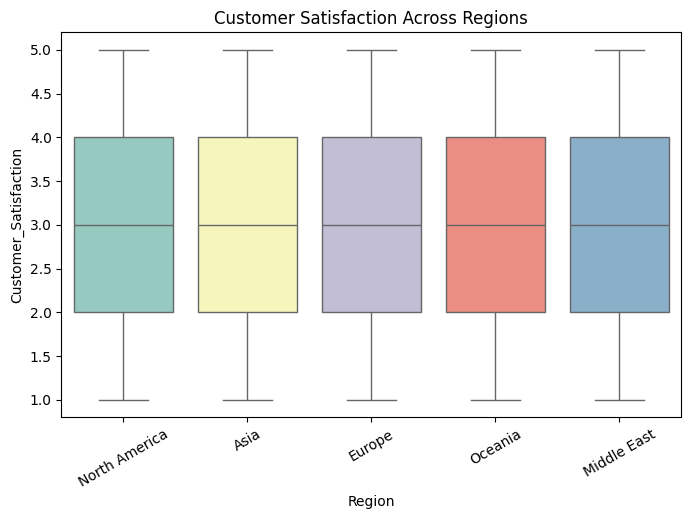

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Region",
    y="Customer_Satisfaction",
    palette="Set3"
)

plt.title("Customer Satisfaction Across Regions")

plt.xticks(rotation=30)

plt.show()

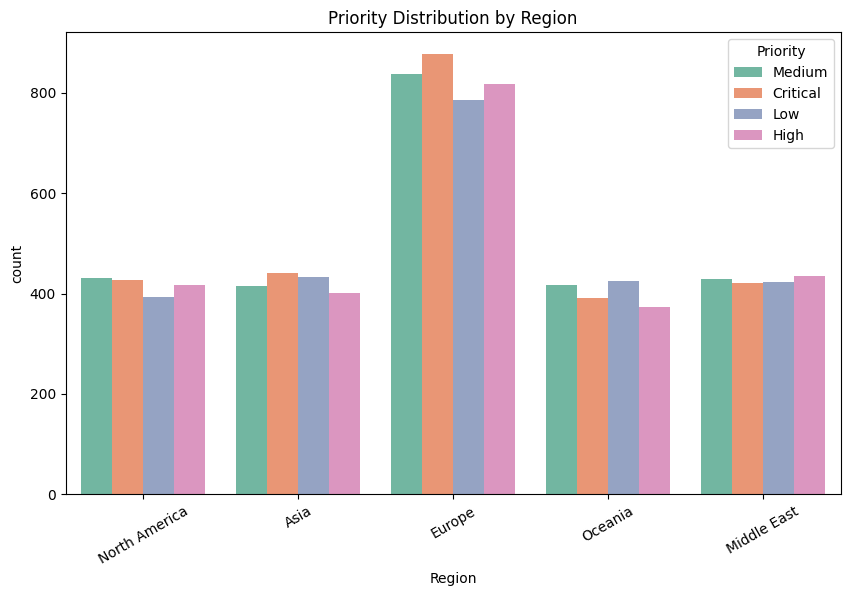

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Region",
    hue="Priority",
    palette="Set2"
)

plt.title("Priority Distribution by Region")

plt.xticks(rotation=30)

plt.show()

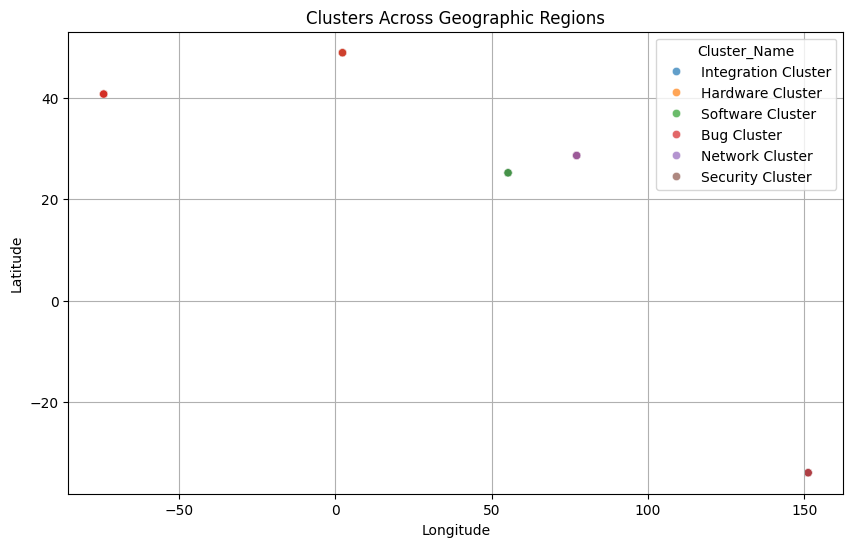

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Cluster_Name",
    alpha=0.7
)

plt.title("Clusters Across Geographic Regions")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)

plt.show()

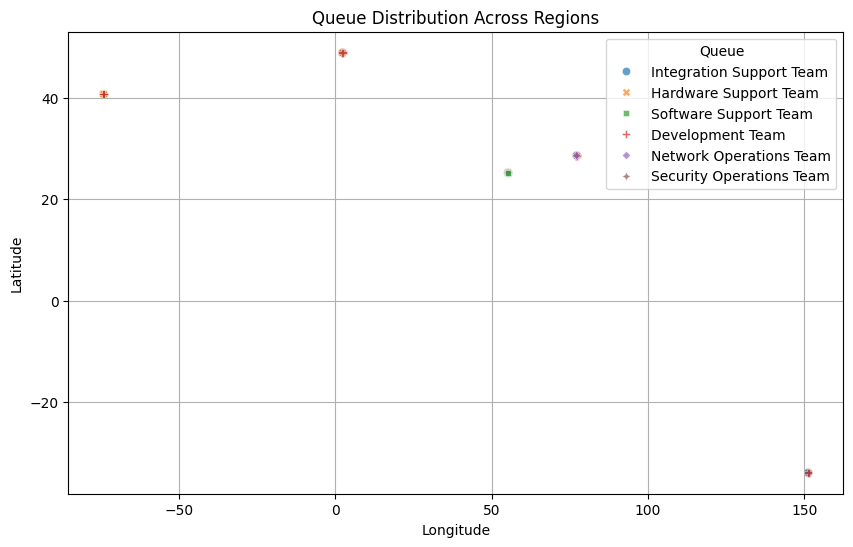

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Queue",
    style="Queue",
    alpha=0.7
)

plt.title("Queue Distribution Across Regions")

plt.grid(True)

plt.show()

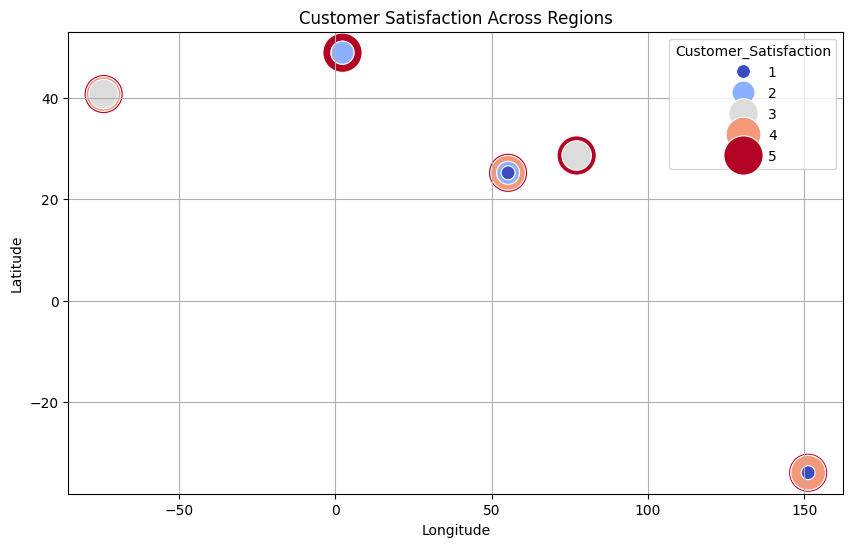

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    size="Customer_Satisfaction",
    hue="Customer_Satisfaction",
    sizes=(100,800),
    palette="coolwarm"
)

plt.title("Customer Satisfaction Across Regions")

plt.grid(True)

plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_geo(
    df,
    lat="Latitude",
    lon="Longitude",
    color="Category",
    size="Priority_Score",
    hover_name="Region",
    projection="natural earth",
    title="Global Distribution of IT Support Tickets"
)

fig.show()

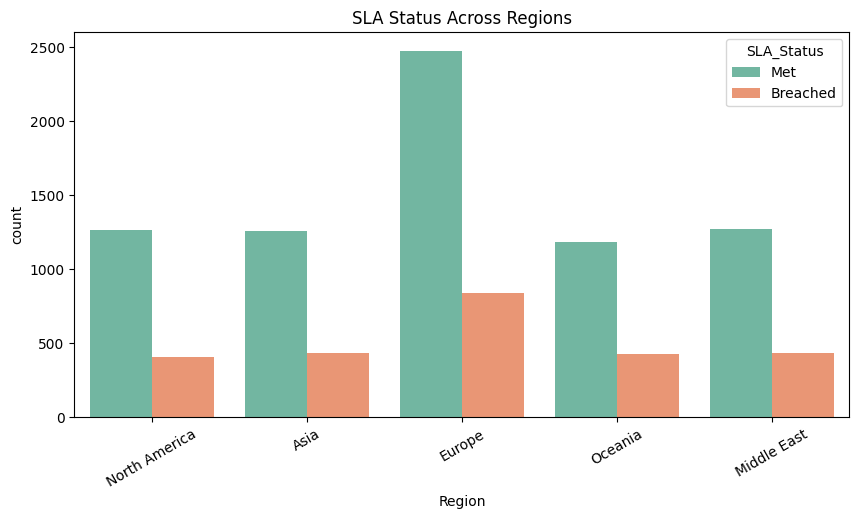

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Region",
    hue="SLA_Status",
    palette="Set2"
)

plt.title("SLA Status Across Regions")
plt.xticks(rotation=30)
plt.show()

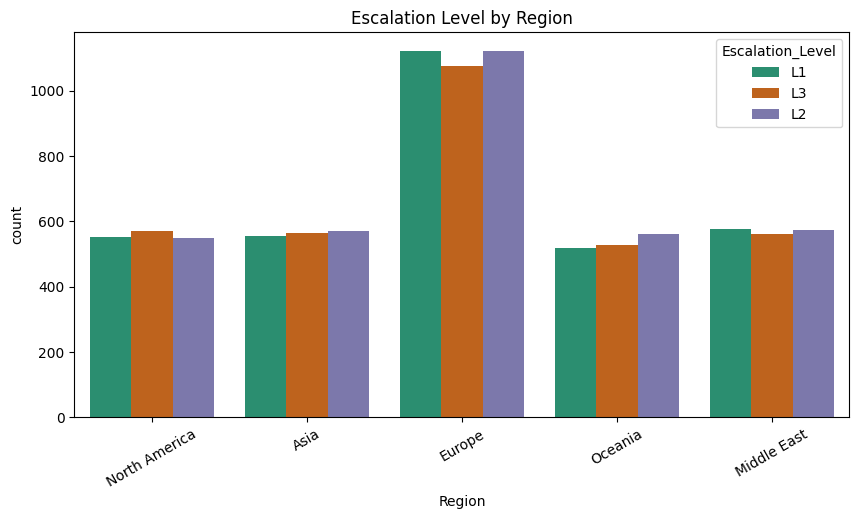

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Region",
    hue="Escalation_Level",
    palette="Dark2"
)

plt.title("Escalation Level by Region")
plt.xticks(rotation=30)
plt.show()

/tmp/ipykernel_756/3006321794.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




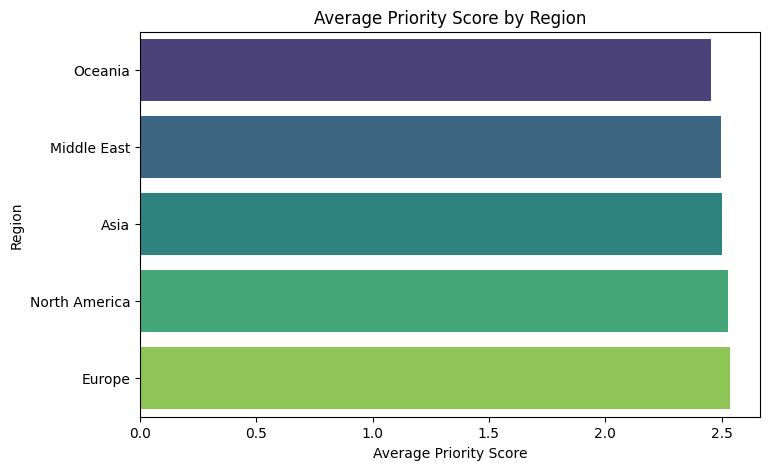

In [ ]:
plt.figure(figsize=(8,5))

avg = df.groupby("Region")["Priority_Score"].mean().sort_values()

sns.barplot(
    x=avg.values,
    y=avg.index,
    palette="viridis"
)

plt.title("Average Priority Score by Region")
plt.xlabel("Average Priority Score")
plt.show()

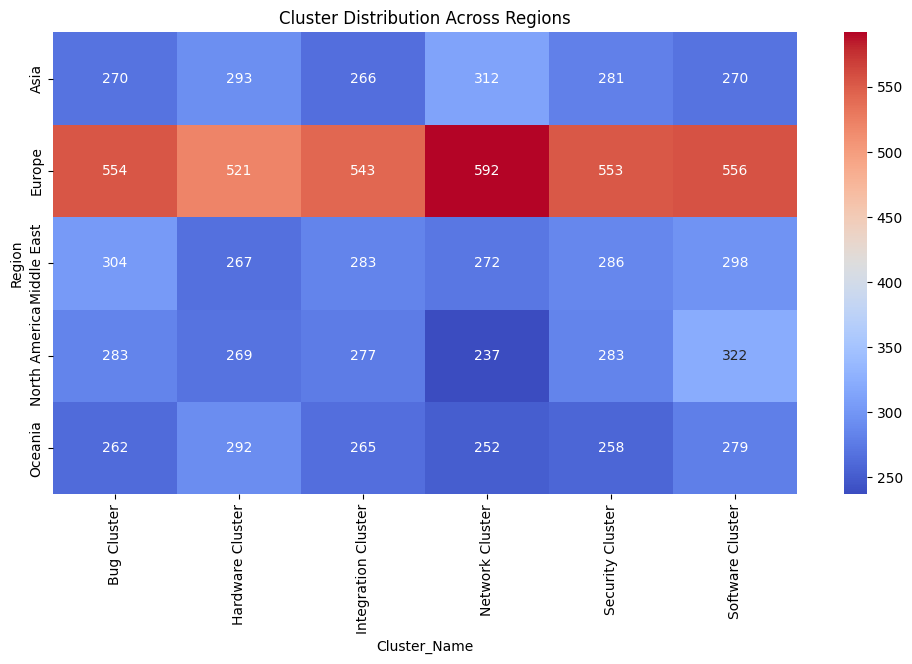

In [ ]:
pivot = pd.crosstab(df["Region"], df["Cluster_Name"])

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm",
    fmt="d"
)

plt.title("Cluster Distribution Across Regions")
plt.show()

/tmp/ipykernel_756/2109190936.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




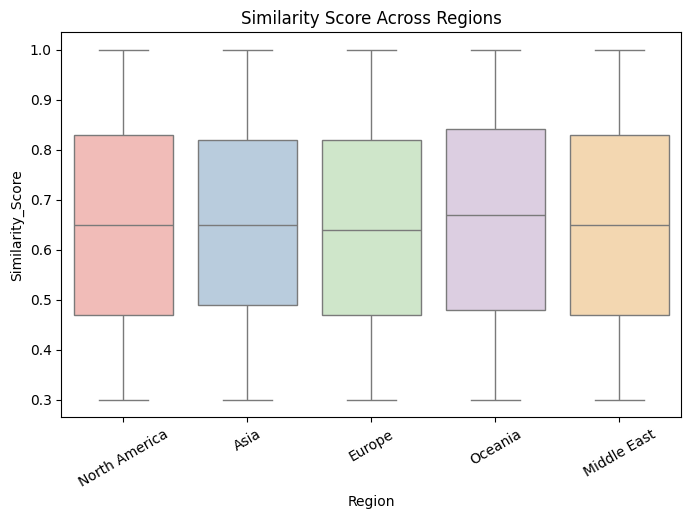

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Region",
    y="Similarity_Score",
    palette="Pastel1"
)

plt.title("Similarity Score Across Regions")
plt.xticks(rotation=30)
plt.show()